# TS0 - Primeros pasos en la simulación

## Introducción
En este trabajo se ha implementado un generador de señales senoidales utilizando Python. 
Se ha desarrollado una función que ha permitido modificar parámetros como la amplitud, el valor medio, la frecuencia y la fase de la señal.
Además, se han tenido en cuenta la frecuencia de muestreo y el número de muestras para observar cómo se representa una señal en un entorno digital. 
Posteriormente se realizaron diferentes experimentos modificando la frecuencia para analizar los efectos que aparecen durante el muestreo.

## Parámetros fijos de la simulación

Para las simulaciones se utilizarán una frecuencia de muestreo de 1000 Hz y un total de 1000 muestras. 
La frecuencia de muestreo indica cuántas muestras de la señal son tomadas cada segundo. Por tanto, al utilizar 1000 muestras, con la frecuencia de 1000 Hz estaríamos representando un segundo de la señal.
Además, teniendo cuenta el criterio de Nyquist, la frecuencia máxima que podemos representar correctamente con esta frecuencia de muestreo es: 
$$f_N = \frac{f_s}{2} = \frac{1000}{2} = 500\ Hz$$

Este valor será importante posteriormente para analizar qué ocurre cuando la frecuencia de una señal alcanza o supera la frecuencia de Nyquist y observar la aparición del fenomeno de aliasing.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros fijos de la simulación
fs = 1000
N = 1000


## Generación de la señal senoidal 

Ya tenemos todo importado y podemos generar nuestra función para la señal senoidal 

In [24]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    
    # Vector con los instantes de tiempo en los que se toman las muestras
    tt = np.arange(nn) / fs
    
    # Valores de la Señal senoidal
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    # La funcion devuelve el vector de tiempo y la señal
    return tt, xx


Teniendo ya la funcion del seno, vamos a crear nuestra función que permita graficar la señal. He creado una función que me permita elegir el parametro de ff y así cuando tengamos que probar con distintos valores de ff, simplemente llamamos a la función y ponemos el valor que queremos.

In [25]:
def graficar_senoidal(ff):
    
    tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)
    
    plt.figure(figsize=(10, 4))
    plt.plot(tt, xx, label=f'ff = {ff} Hz')
    plt.title('TP0: Señal senoidal')
    plt.xlabel('Tiempo [Segundos]')
    plt.ylabel('Amplitud [Volts]')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

Para probarla vamos a empezar poniendo ff = 1

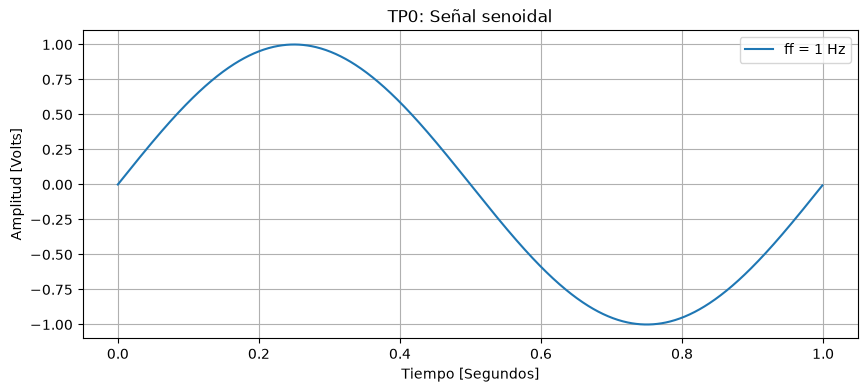

In [26]:
graficar_senoidal(1)

En esta gráfica estamos representando un segundo de señal. Como la frecuencia elegida es de 1 Hz, durante ese segundo podemos observar un ciclo completo de la senoide. Además, la señal presenta una amplitud de 1 V y está centrada en 0 V, tal y como esperábamos según los parámetros definidos.

A continuación se probará la señal senoidal con diferentes valores de frecuencia, manteniendo constantes la frecuencia de muestreo fs=1000 Hz y el número de muestras N=1000. El objetivo es observar cómo cambia la señal representada al acercarnos y superar la frecuencia de Nyquist, que en este caso es de 500 Hz.

La primera frecuencia que vamos a utilizar es la de ff=500 que es justo la de Nyquist. 
Para graficar simplemente llamo a mi función y le doy ese valor.

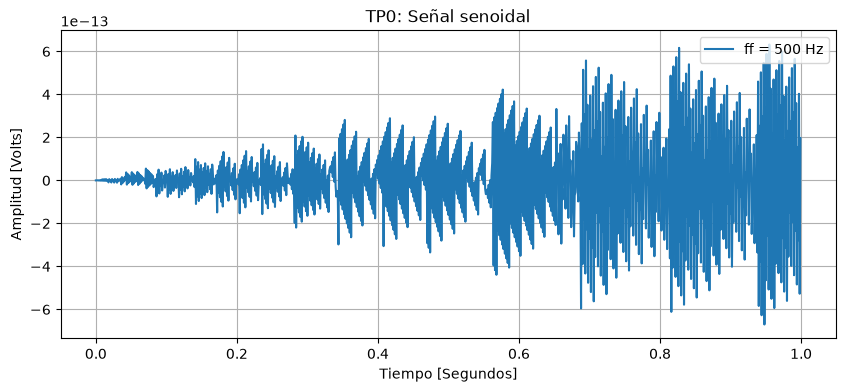

In [27]:
graficar_senoidal(500)

Al utilizar la frecuencia de Nyquist, estamos justo en el límite. Esto implica que solo disponemos de dos muestras (1000Hz/500Hz = 2) por cada ciclo de la señal, por lo que tenemos muy poca información sobre su forma.

Por este motivo, aunque estamos generando una señal de 500 Hz, en la gráfica no podemos apreciar correctamente su forma senoidal y observamos valores prácticamente nulos.

Además, aparecen pequeñas variaciones alrededor de cero que se deben a errores de precisión numérica en los cálculos y no a oscilaciones reales de la señal. Este caso permite observar que trabajar exactamente en la frecuencia de Nyquist es una situación límite y que dos muestras por periodo no permiten visualizar correctamente la forma de la señal.

Ahora probamoscon una ff=999

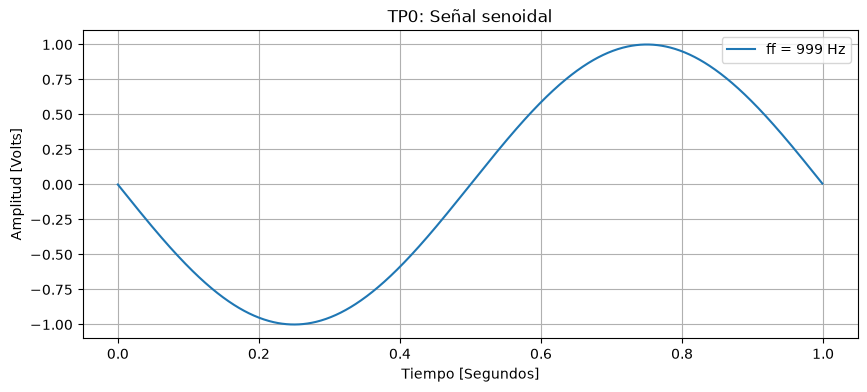

In [34]:
graficar_senoidal(999)

En este caso sí podemos apreciar una forma senoidal en la gráfica, pero esta no corresponde realmente a una señal de 999 Hz. Como esta frecuencia supera la frecuencia de Nyquist, aparece el fenómeno de aliasing y la señal se representa como si tuviera una frecuencia mucho menor. En concreto, al estar 999 Hz a solo 1 Hz de la frecuencia de muestreo de 1000 Hz, obtenemos una frecuencia aparente de 1 Hz. Por eso observamos un único ciclo durante el segundo representado. Además, la señal aparece invertida respecto a la señal original de 1 Hz.

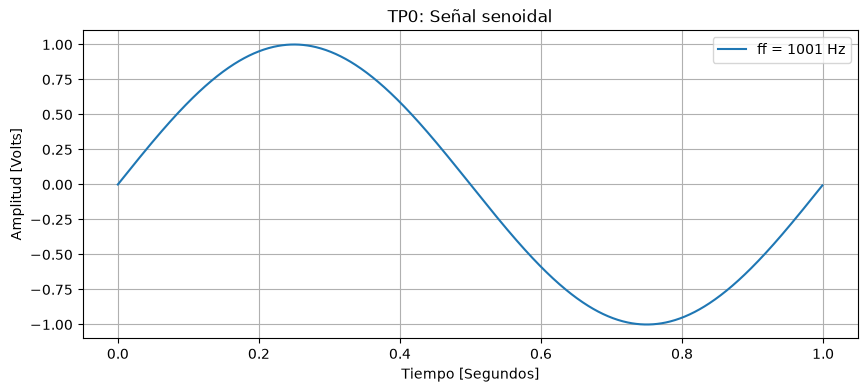

In [35]:
graficar_senoidal(1001)

En este caso la frecuencia de la señal es de 1001 Hz, por lo que vuelve a superar la frecuencia de Nyquist y se produce aliasing. Aunque la señal original tiene una frecuencia muy elevada, en la gráfica observamos una senoide que realiza únicamente un ciclo durante el segundo representado, es decir, aparenta tener una frecuencia de 1 Hz. Esto ocurre porque la frecuencia de la señal está 1 Hz por encima de la frecuencia de muestreo (1001−1000=1 Hz), por lo que las muestras obtenidas coinciden con las que obtendríamos para una señal de 1 Hz. A diferencia del caso de 999 Hz, en este caso la señal no aparece invertida.

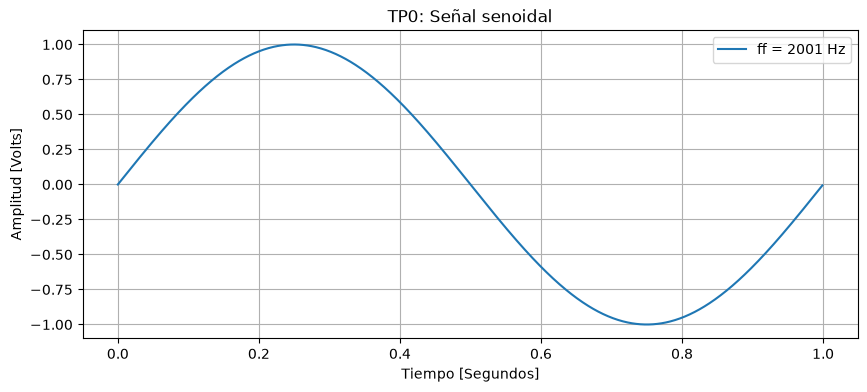

In [36]:
graficar_senoidal(2001)

En este último caso la frecuencia de la señal es de 2001 Hz, por lo que se encuentra muy por encima de la frecuencia de Nyquist y vuelve a producirse aliasing. Sin embargo, observamos nuevamente una señal aparente de 1 Hz. Esto ocurre porque 2001 Hz se encuentra 1 Hz por encima de dos veces la frecuencia de muestreo (2001−2⋅1000=1 Hz). Por tanto, aunque la señal original realiza 2001 ciclos por segundo, las muestras obtenidas no permiten distinguirla de una señal de 1 Hz. Este resultado muestra que distintas frecuencias pueden producir exactamente las mismas muestras cuando no se cumple el criterio de Nyquist.

# Señal triangular

Como última parte de la práctica, vamos a implementar otro tipo de señal que podemos encontrar en un generador de señales. En este caso se ha elegido una señal triangular.

A diferencia de la señal senoidal, cuya amplitud varía de forma suave siguiendo una función seno, la señal triangular está formada por tramos lineales en los que la amplitud aumenta y disminuye de manera constante. Al igual que la senoide, es una señal periódica, por lo que su forma se repite con una frecuencia determinada.

He implementado la sguiente función, que es parecida a la de la señal senoidal pero en este caso utilizo la combinación de las funciones seno y arcoseno para conseguir la forma triangular. Se mantienen los mismos parámetros de amplitud, valor medio, frecuencia y fase, por lo que podemos modificarlos de la misma manera que en la función anterior.

In [37]:
def mi_funcion_triangular(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = vmax * (2 / np.pi) * np.arcsin(
        np.sin(2 * np.pi * ff * tt + ph)
    ) + dc

    return tt, xx

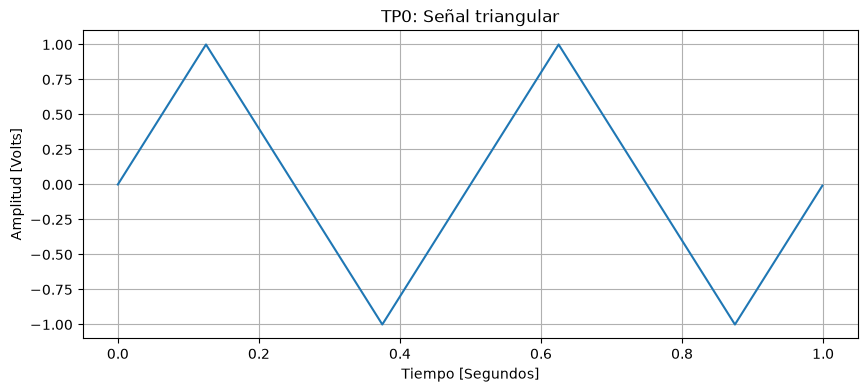

In [38]:
tt, xx = mi_funcion_triangular(
    vmax=1,
    dc=0,
    ff=2,
    ph=0,
    nn=N,
    fs=fs
)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx)
plt.title('TP0: Señal triangular')
plt.xlabel('Tiempo [Segundos]')
plt.ylabel('Amplitud [Volts]')
plt.grid(True)
plt.show()


En la gráfica podemos observar como la amplitud aumenta y disminuye de forma lineal entre 1V y −1V. En este caso se ha utilizado una frecuencia de 2 Hz, por lo que durante el segundo representado aparecen dos ciclos completos.

# Conclusión

En este proyecto hemos podido estudiar de forma experimental cómo se generan y se representan señales utilizando Python, prestando especial atención a la relación entre la frecuencia de la señal y la frecuencia de muestreo.

Hemos trabajado con una frecuencia de muestreo de 1000 Hz, por lo que la frecuencia de Nyquist es de 500 Hz. A partir de las distintas pruebas realizadas podemos sacar varias conclusiones:

1. Frecuencias por debajo de Nyquist: cuando la frecuencia de la señal está suficientemente por debajo de 500 Hz disponemos de varias muestras por cada ciclo, por lo que podemos representar correctamente su comportamiento. Cuanto mayor sea la frecuencia de la señal, tendremos menos muestras disponibles por ciclo y será más difícil apreciar su forma.
   
2. Frecuencia de Nyquist (500 Hz): al llegar a este límite únicamente disponemos de dos muestras por cada ciclo. Esto hace que tengamos muy poca información sobre la señal y que su forma senoidal no pueda apreciarse correctamente en la gráfica. Este caso nos permite ver por qué trabajar justo en el límite de Nyquist puede resultar problemático.

3. Frecuencias superiores a Nyquist: con las pruebas de 999 Hz, 1001 Hz y 2001 Hz hemos podido observar el fenómeno de aliasing. Aunque las señales originales tienen frecuencias muy elevadas, las muestras obtenidas hacen que aparezcan como señales de una frecuencia mucho menor. Por ejemplo, en estos casos hemos obtenido señales aparentes de aproximadamente 1 Hz, a pesar de que esa no era la frecuencia real que habíamos introducido.

Esto nos ha permitido comprobar de forma visual que, cuando no se cumple el criterio de Nyquist, diferentes señales pueden producir muestras que parecen corresponder a una frecuencia distinta y, por tanto, podemos interpretar incorrectamente la señal original.

Por último, hemos implementado también una señal triangular, utilizando los mismos parámetros principales que en la señal senoidal. De esta forma hemos comprobado que podemos adaptar el generador para trabajar con diferentes tipos de señales y observar sus distintas formas.

En general, esta práctica nos ha ayudado a entender de una forma mucho más visual conceptos como la frecuencia de muestreo, la frecuencia de Nyquist y el aliasing.